In [1]:
source("Utils.R")
library("ggplot2")

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()
df <- vasijas_X

In [3]:
a <- apply(df, 2, function(x) c(quantile(x, 0.025), quantile(x, 0.5), quantile(x, 0.975)))
x = 100:400
ymin = as.double(a[1, ])
y.500 = as.double(a[2, ])
ymax = as.double(a[3, ])

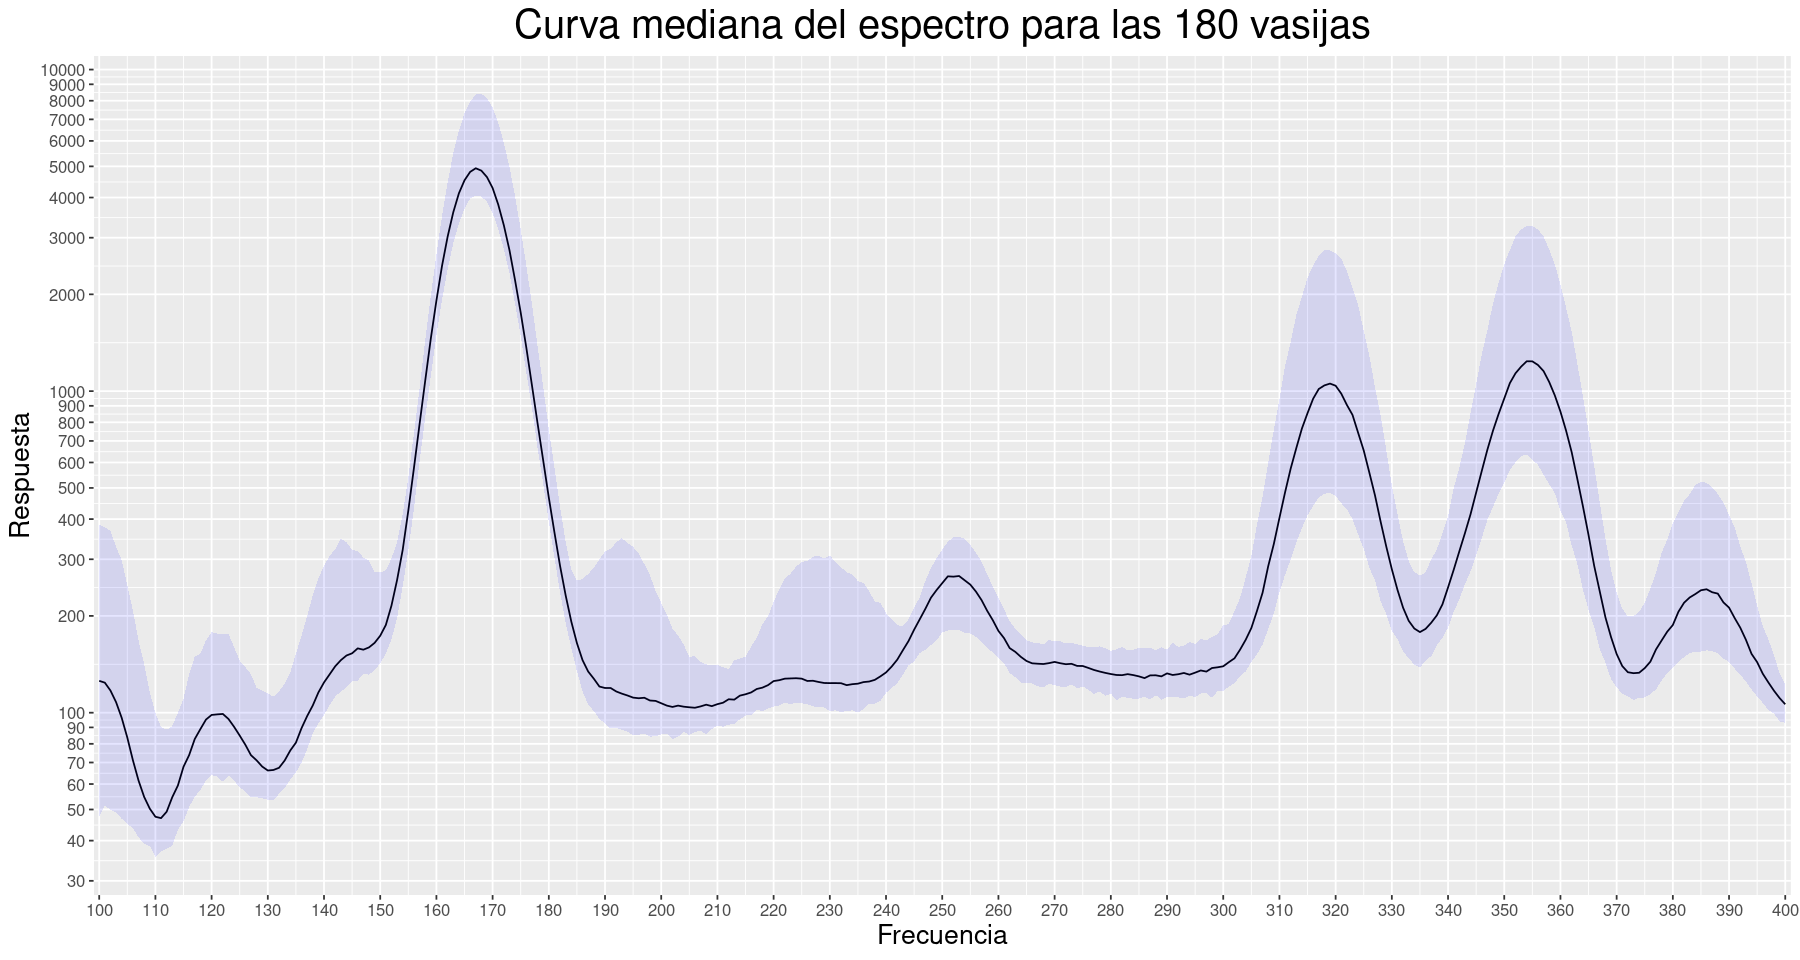

In [4]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))
ggplot() +
    geom_line(aes(x=x, y=y.500)) +
    geom_ribbon(aes(x=x, ymin=ymin, ymax=ymax), fill="blue", alpha=0.1) +
    scale_y_continuous(trans='log10', breaks=c(seq(0, 90, 10), seq(100, 900, by=100), seq(1000, 10000, 1000))) + 
    scale_x_continuous(breaks = seq(100, 400, by=10), expand = c(0, 1)) +
    ggtitle("Curva mediana del espectro para las 180 vasijas") + 
    xlab("Frecuencia") + ylab("Respuesta")

In [5]:
ggplot(a) +
  geom_line(aes(x=x, y = y.500))
  geom_ribbon(aes(ymin=y.025,ymax=y.975), fill="blue", alpha=0.5)
  #scale_y_continuous(expand = c(0, 0), limits=c(0,20)) +
  #scale_x_continuous(expand = c(0, 0), limits=c(0,5)) + 
  #scale_fill_manual(values=c(clear,blue))

ERROR: Error: `data` must be a data frame, or other object coercible by `fortify()`, not a numeric vector.


In [ ]:
summary(vasijas_Y)

In [ ]:
sd(vasijas_Y)^2

# Prueba de normalidad

In [209]:
library(dgof)
library(ggplot2)
library(nortest)

In [271]:
options(warn=-1) # Borro el warning que lanza por repetidos.


setSeed()

X <- scale(vasijas_X)
n <- length(X[, 1])
ps <- c()
for (i in 1:301) {
    p <- lillie.test(X[, i])$p
    ps <- c(ps, p)
}

options(warn=0)

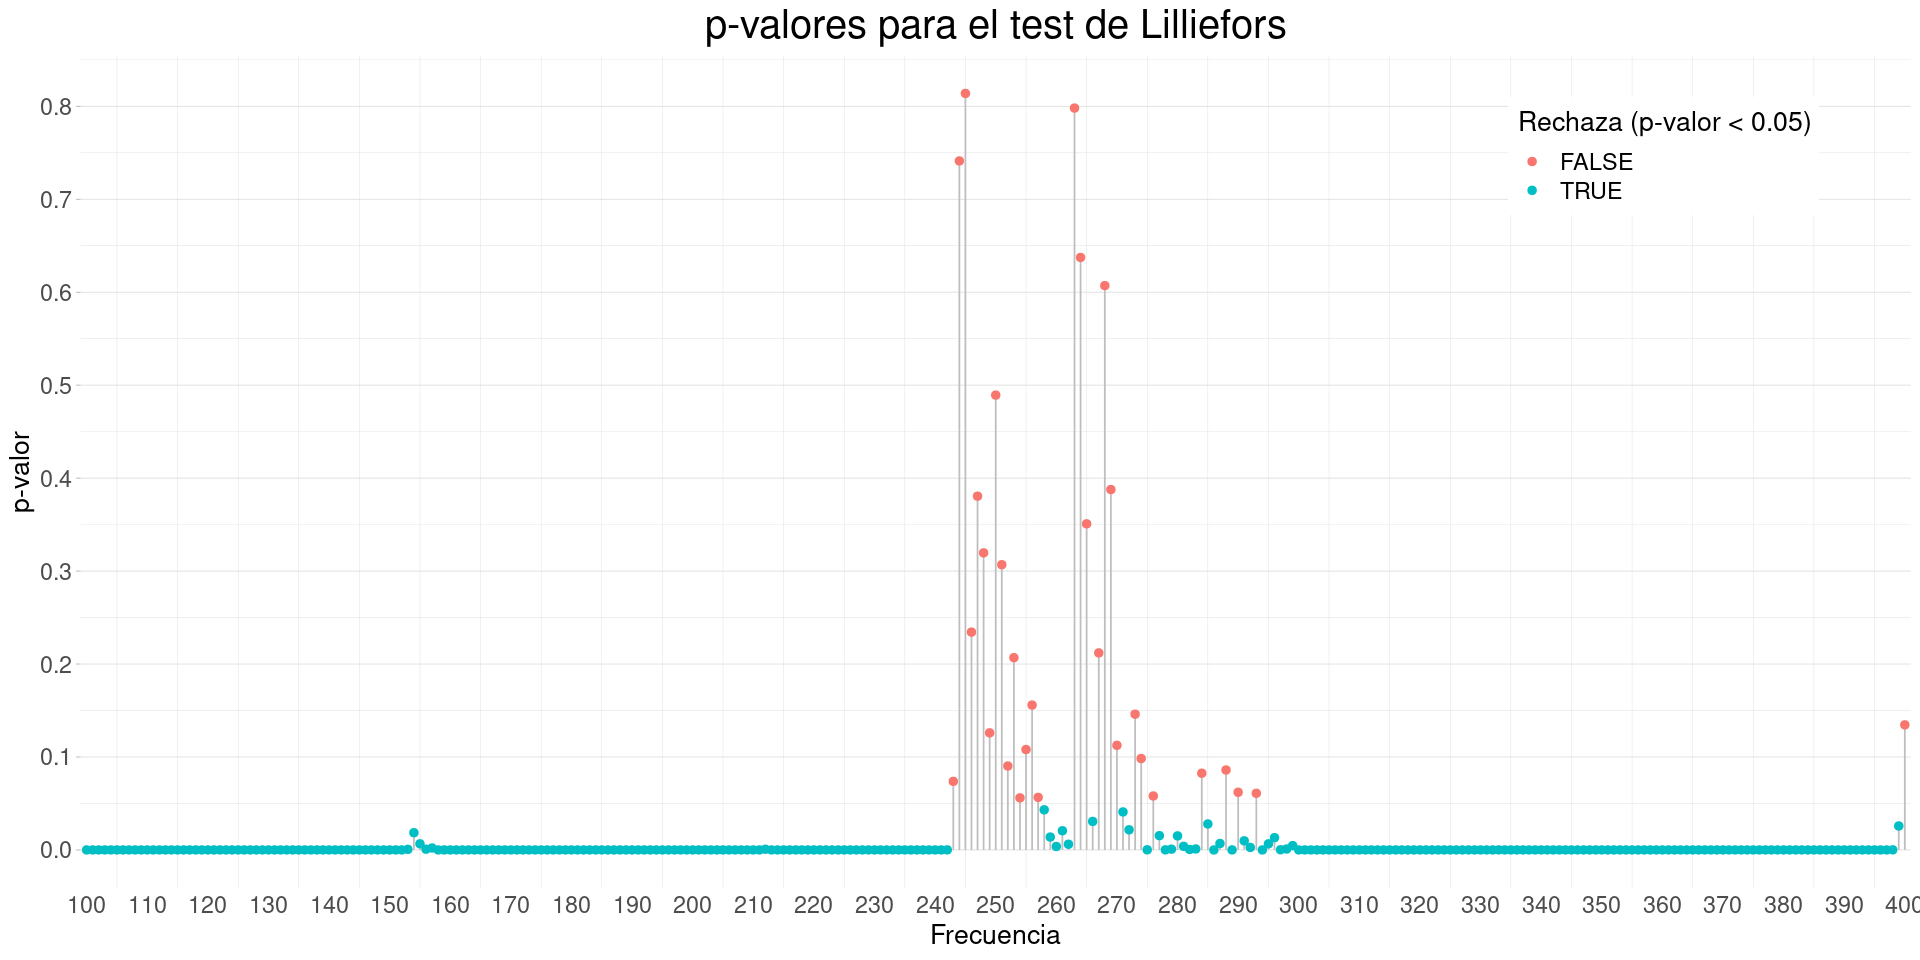

In [272]:
x_plot = as.integer(sub('.', '', colnames(vasijas_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=ps,
  col=ps<0.05
)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y, col=col)) +
  ggtitle("p-valores para el test de Lilliefors") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  scale_x_continuous(breaks = seq(100, 400, by=10), expand = c(0,1)) +
  scale_y_continuous(breaks = seq(0, 1, by=0.1)) +
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  xlab("Frecuencia") + ylab("p-valor")

[1] 1.605718e-15

In [277]:
options(warn=-1) # Borro el warning que lanza por repetidos.


setSeed()

X <- scale(vasijas_X)
n <- length(X[, 1])
ps <- c()
for (i in 1:301) {
    p <- shapiro.test(X[, i])$p
    ps <- c(ps, p)
}

options(warn=0)

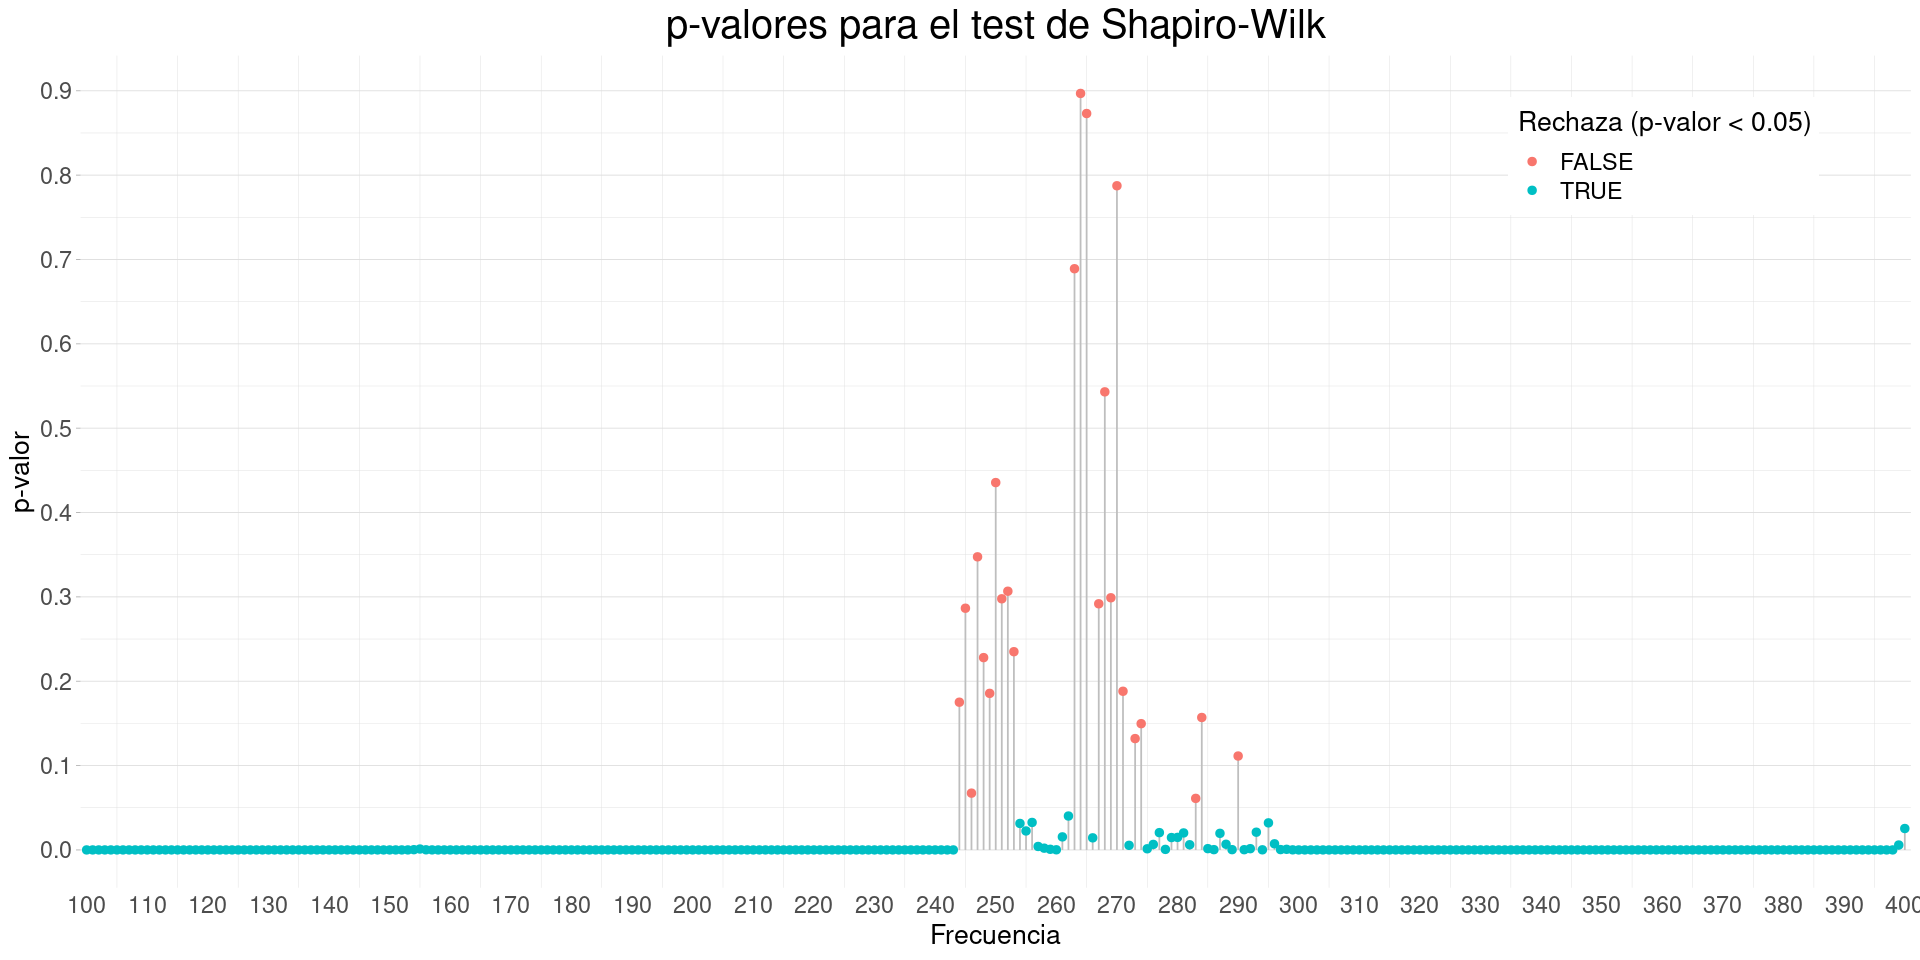

In [279]:
x_plot = as.integer(sub('.', '', colnames(vasijas_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=ps,
  col=ps<0.05
)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y, col=col)) +
  ggtitle("p-valores para el test de Shapiro-Wilk") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  scale_x_continuous(breaks = seq(100, 400, by=10), expand = c(0,1)) +
  scale_y_continuous(breaks = seq(0, 1, by=0.1)) +
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  xlab("Frecuencia") + ylab("p-valor")